# Imports

In [1]:
import pandas            as pd
import matplotlib.pyplot as plt
import numpy             as np
import matplotlib.colors as colors

import matplotlib
import sys


sys.path.append('/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk')

# Import Diego's tools
from WCSimFilePackages.npz_to_df     import simple_truehits_info_to_df, truehits_info_to_df, digihits_info_to_df
from WCSimFilePackages.npz_to_df     import super_simple_track_info_to_df, simple_track_info_to_df, track_info_to_df
from WCTE_event_display.EventDisplay import EventDisplay

from tqdm.notebook import tqdm

import hipy.hipy.pltext as pltext
import hipy.hipy.utils  as ut

pd.set_option('display.max_rows', 100000)
pd.set_option('display.max_columns', 100000)

%load_ext autoreload
%autoreload 2

pltext.style()

# Read Data

In [2]:
npz_1767 = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/rootFiles/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1767_CDSON_15kevents.npz'
nevents  = 15000

# Creación del DataFrame de DigiHits usando la función digihits_info_to_df
df_trueHits_1767 = truehits_info_to_df(npz_1767).dropna()
# df_digiHits_1767 = digihits_info_to_df(npz_1767, nevents).dropna()
# df_simpleTracks_1767 = simple_track_info_to_df(npz_1767).dropna()

# df_simpleTracks_1767 = df_simpleTracks_1767[df_simpleTracks_1767["track_ti"] <= 500000]

In [3]:
# df_simpleTracks_1767["type"] = None

# mask_nCapture_gamma = (df_simpleTracks_1767["track_pid"] == 22) & (df_simpleTracks_1767["track_creator_process"] == "nCapture")
# mask_H = mask_nCapture_gamma & (df_simpleTracks_1767["track_energy"] >= 2.20) & (df_simpleTracks_1767["track_energy"] <= 2.25)
# mask_Ni = mask_nCapture_gamma & ~mask_H

# df_simpleTracks_1767.loc[mask_H, "type"]  = "H"
# df_simpleTracks_1767.loc[mask_Ni, "type"] = "Ni"

# print(df_simpleTracks_1767["type"].value_counts(dropna=False))

In [4]:
df_trueHits_1767.head()

,event_id,true_hit_parent,true_hit_pmt,true_hit_time,true_hit_start_time,hit_x,hit_y,hit_z,hit_start_x,hit_start_y,hit_start_z,hit_r,hit_start_r
0,0,55,67,20284.443359,20276.630859,142.201767,-25.467146,55.756996,14.068387,44.841469,-35.371704,154.850769,58.820356
0,0,55,59,20284.609375,20276.623047,136.363052,-35.414623,58.661827,14.02679,44.948112,-35.48391,152.611558,58.959236
0,0,55,59,20284.740234,20276.623047,136.270493,-32.260418,64.741653,14.02049,44.977707,-35.507191,154.278525,58.994312
0,0,55,66,20285.015625,20276.621094,136.850372,-29.30098,65.81044,14.017797,44.990353,-35.517136,154.653115,59.009299
0,0,55,310,20285.150391,20276.630859,50.821846,5.157138,141.716522,14.068939,44.817726,-35.330299,150.642055,58.777493


In [5]:
# df_simpleTracks_1767.head()

In [6]:
df_tracks_1767 = track_info_to_df(npz_1767).dropna()

In [7]:
df_tracks_1767["type"] = None

mask_nCapture_gamma = (df_tracks_1767["track_pid"] == 22) & (df_tracks_1767["track_creator_process"] == "nCapture")
mask_H = mask_nCapture_gamma & (df_tracks_1767["track_energy"] >= 2.20) & (df_tracks_1767["track_energy"] <= 2.25)
mask_Ni = mask_nCapture_gamma & ~mask_H

df_tracks_1767.loc[mask_H, "type"]  = "H"
df_tracks_1767.loc[mask_Ni, "type"] = "Ni"

print(df_tracks_1767["type"].value_counts(dropna=False))

type
None    27806287
H          48517
Ni         18874
Name: count, dtype: int64


# Map PMT ID And Hit Map

In [ ]:
#1) make an instance of the event display class
eventDisplay = EventDisplay() 

#2) start by loading in the CSV file for how the mPMTs are mapped to 2d event display
#unwraps based on the mPMT slot ID 
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')

#mask out mPMT slots - newer WCSim doesn't have these mPMTs loaded  
#WCTE slot numbering
# eventDisplay.mask_mPMTs([45,77,79,27,32,85,91,99,12,14,16,18])
#WCSim container numbering
# eventDisplay.mask_mPMTs([20,73,38,49,55,65,67,33,71,92,101,95])

#3) load the WCSim mapping tube no to slot number
#for WCSim using the numpy output we need the mapping between the tube_number in WCSim and the slot and mPMT number in the detector
#this can be obtained from the geofile that WCSim produces 
#This changes if the CDS is implemented or not
eventDisplay.load_wcsim_tubeno_mapping("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt")

In [ ]:
data = df_digiHits_1767
tube_no = data["digi_hit_pmt"] + 1
data_to_plot = data["digi_hit_charge"]

#map from the tube number to the mPMT slot and position number
mPMT_id_1767, PMT_pos_1767 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
data_to_plot = eventDisplay.process_data(mPMT_id_1767, PMT_pos_1767, data_to_plot)
eventDisplay.plotEventDisplay(data_to_plot, color_norm=None, style="dark_background")

plt.style.use('default');
pltext.style()

In [ ]:
mc      = df_digiHits_1767
n_pmts  = 2014
tube_no = mc["digi_hit_pmt"] + 1

mPMT_id_1767, PMT_pos_1767 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
mc_pmt_id                  = mPMT_id_1767 * 19 + PMT_pos_1767
df_digiHits_1767["pmt_id"] = mc_pmt_id

nhits_per_pmt = df_digiHits_1767.groupby("pmt_id")["digi_hit_charge"].count().reindex(range(n_pmts), fill_value=0).values.astype(float)


# plot directly
eventDisplay.plotEventDisplay(nhits_per_pmt, color_norm=None, style= "dark_background")

plt.style.use('default');
pltext.style()

In [ ]:
data = df_digiHits_1771
tube_no = data["digi_hit_pmt"] + 1
data_to_plot = data["digi_hit_charge"]

#map from the tube number to the mPMT slot and position number
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
data_to_plot = eventDisplay.process_data(mPMT_id_1771, PMT_pos_1771, data_to_plot)
eventDisplay.plotEventDisplay(data_to_plot,color_norm=colors.LogNorm(), style= "dark_background")

plt.style.use('default');
pltext.style()

In [ ]:
pltext.hist(mPMT_id_1767*19 + PMT_pos_1767,        100, histtype="stepfilled", alpha=0.3, label="PMT ID Map");
pltext.hist(df_digiHits_1767["digi_hit_pmt"], 100, histtype="stepfilled", alpha=0.3, label="PMT ID WCSim");

In [ ]:
pltext.hist(mPMT_id_1771*19 + PMT_pos_1771,   100, histtype="stepfilled", alpha=0.3, label="PMT ID Map");
pltext.hist(df_digiHits_1771["digi_hit_pmt"], 100, histtype="stepfilled", alpha=0.3, label="PMT ID WCSim");

# $t_c$, nHits and $t_{RMS}$

In [ ]:
shifted_times = []
for ev in tqdm(df_trueHits_1767["event_id"].unique(), total=len(df_trueHits_1767["event_id"].unique())):
    temp_df  = df_trueHits_1767[df_trueHits_1767["event_id"].values == ev]
    times    = temp_df["true_hit_time"].values
    min_time = np.min(times)
    shifted_times.append(np.subtract(times, min_time))

df_trueHits_1767["shifted_times"] = np.concatenate(shifted_times)

In [ ]:
tc    = df_trueHits_1767.groupby("event_id")["shifted_times"].mean().values
trms  = df_trueHits_1767.groupby("event_id")["shifted_times"].std().values
nhits = df_trueHits_1767.groupby("event_id")["shifted_times"].size().values

subplot = pltext.canvas(3)

subplot(1)
pltext.hist([i for i in tc if i != 0], 100, ylog=False, range=(0,20), xylabels=r"$t_{c, MC}$ [ns]", label="MC");

subplot(2)
pltext.hist(trms, 100, ylog=False, range=(0,10), xylabels=r"$t_{RMS, MC}$ [ns]", label="MC");

subplot(3)
h = pltext.hist(nhits, 160, ylog=False, xylabels="No. Hits Per Decay [hits]", label="MC");
# Seleccionamos bins dentro del rango
bin_centers = (h[1][:-1] + h[1][1:]) / 2
mask = (bin_centers >= 0) & (bin_centers <= 60)

# Volvemos a dibujar solo esos bins
plt.bar(
    h[1][:-1][mask],
    h[0][mask],
    width=np.diff(h[1])[mask],
    align="edge",
    color="tomato",
    alpha=0.4,
    edgecolor="tomato"
);

In [ ]:
pltext.hist(df_trueHits_1767.groupby("event_id")["true_hit_time"].std().values, 100, stats=False, ylog=False, range=(0, 1e6));

# Hits From nCapture

  0%|          | 0/14943 [00:00<?, ?it/s]

Total candidates: 50451


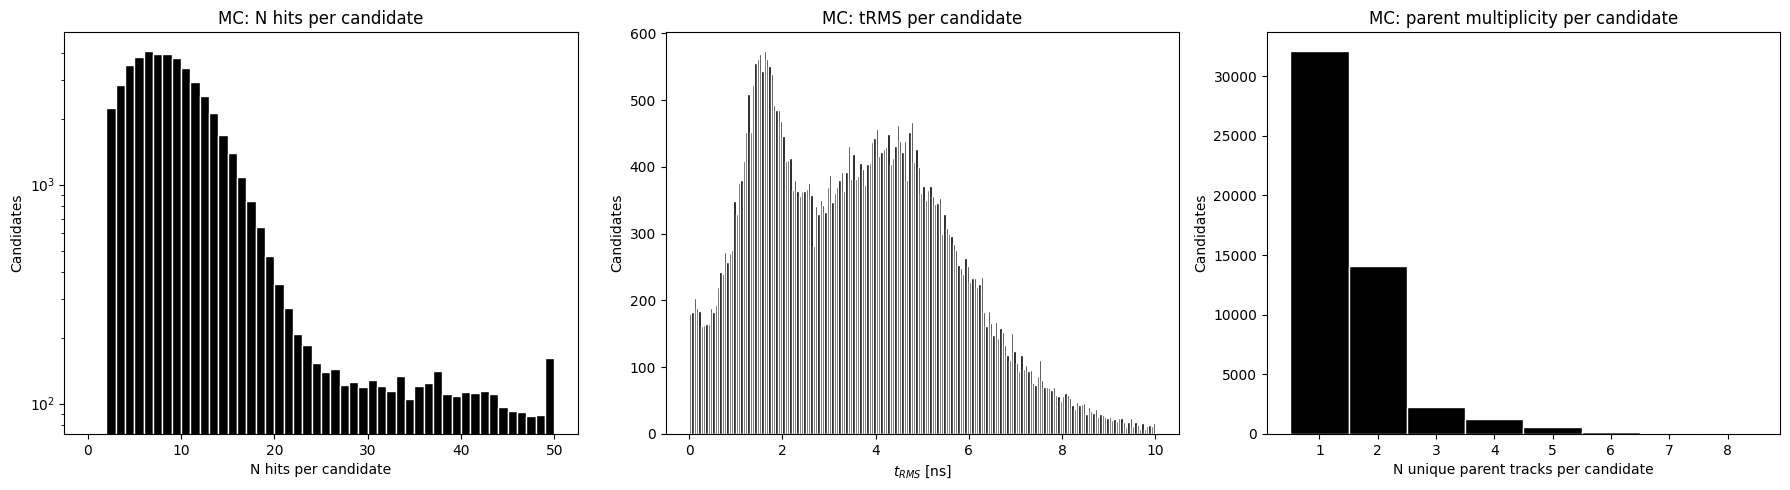


Single parent candidates: 32066
  Mean nhits: 9.5, Mean tRMS: 3.561 ns

Multi parent candidates:  18385
  Mean nhits: 14.7, Mean tRMS: 3.681 ns


In [4]:
# --- Greedy nHits trigger for simulation ---
# Same parameters as data: w=20 ns, thresh_min=2, no thresh_max

def nHits_greedy_sim(hit_times, hit_pmts, hit_parents,
                     w=20, thresh_min=2, thresh_max=None, jump=0):
    """
    Greedy nHits trigger on a single event from simulation.
    Returns list of candidates, each a dict with indices, times, pmts, parents.
    """
    if len(hit_times) == 0:
        return []

    # Sort by time
    sort_idx = np.argsort(hit_times)
    ht   = hit_times[sort_idx]
    hpmt = hit_pmts[sort_idx]
    hpar = hit_parents[sort_idx]
    n    = len(ht)

    # Sliding window counts
    ends   = ht + w
    right  = np.searchsorted(ht, ends, side="left")
    counts = right - np.arange(n)

    candidates = []
    last_cluster_end = -np.inf
    i = 0

    while i < n:
        if ht[i] < last_cluster_end + jump:
            i += 1
            continue

        if counts[i] < thresh_min:
            i += 1
            continue

        if thresh_max is not None and counts[i] > thresh_max:
            i += 1
            continue

        # Trigger
        seed = ht[i]
        collected_end = right[i]

        # Greedy extension
        while collected_end < n:
            t_last = ht[collected_end - 1]
            next_end = np.searchsorted(ht, t_last + w, side="left")
            if next_end > collected_end:
                collected_end = next_end
            else:
                break

        # Save candidate
        idx = sort_idx[i:collected_end]
        candidates.append({
            "hit_indices" : idx,
            "hit_times"   : ht[i:collected_end],
            "hit_pmts"    : hpmt[i:collected_end],
            "hit_parents" : hpar[i:collected_end],
            "seed_time"   : seed,
            "nhits"       : collected_end - i,
            "trms"        : np.std(ht[i:collected_end]),
            "tc"          : (ht[i:collected_end] - ht[i]).mean(),
            "duration"    : ht[collected_end-1] - ht[i],
        })

        last_cluster_end = ht[collected_end - 1]
        i = collected_end

    return candidates


# --- Run trigger on all events ---
all_candidates = []
global_cand_id = 0

for event_id, event_df in tqdm(df_trueHits_1767.groupby("event_id"), total=len(df_trueHits_1767.groupby("event_id"))):
    
    ht   = event_df["true_hit_time"].values
    hpmt = event_df["true_hit_pmt"].values
    hpar = event_df["true_hit_parent"].values
    
    candidates = nHits_greedy_sim(ht, hpmt, hpar, w=20, thresh_min=2)
    
    for cand in candidates:
        cand["event_id"]      = event_id
        cand["candidate_id"]  = global_cand_id
        # Most common parent = dominant process
        parents, counts = np.unique(cand["hit_parents"], return_counts=True)
        cand["dominant_parent"] = parents[counts.argmax()]
        cand["n_unique_parents"] = len(parents)
        global_cand_id += 1
    
    all_candidates.extend(candidates)

print(f"Total candidates: {len(all_candidates)}")

# --- Summary DataFrame ---
df_cands = pd.DataFrame([{
    "event_id"         : c["event_id"],
    "candidate_id"     : c["candidate_id"],
    "nhits"            : c["nhits"],
    "trms"             : c["trms"],
    "tc"               : c["tc"],
    "duration"         : c["duration"],
    "seed_time"        : c["seed_time"],
    "dominant_parent"  : c["dominant_parent"],
    "n_unique_parents" : c["n_unique_parents"],
} for c in all_candidates])

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# N hits
axes[0].hist(df_cands["nhits"], bins=50, range=(0, 50), color='black', edgecolor='white')
axes[0].set_xlabel("N hits per candidate")
axes[0].set_ylabel("Candidates")
axes[0].set_title("MC: N hits per candidate")
axes[0].set_yscale('log')

# tRMS
axes[1].hist(df_cands["trms"], bins=200, range=(0, 10), color='black', edgecolor='white')
axes[1].set_xlabel("$t_{RMS}$ [ns]")
axes[1].set_ylabel("Candidates")
axes[1].set_title("MC: tRMS per candidate")

# N unique parents per candidate
axes[2].hist(df_cands["n_unique_parents"], bins=range(1, 10), color='black', edgecolor='white', align='left')
axes[2].set_xlabel("N unique parent tracks per candidate")
axes[2].set_ylabel("Candidates")
axes[2].set_title("MC: parent multiplicity per candidate")

plt.tight_layout()
plt.show()

# --- Key question: do candidates with multiple parents have higher tRMS? ---
single_parent = df_cands[df_cands["n_unique_parents"] == 1]
multi_parent  = df_cands[df_cands["n_unique_parents"] > 1]

print(f"\nSingle parent candidates: {len(single_parent)}")
print(f"  Mean nhits: {single_parent['nhits'].mean():.1f}, Mean tRMS: {single_parent['trms'].mean():.3f} ns")
print(f"\nMulti parent candidates:  {len(multi_parent)}")
print(f"  Mean nhits: {multi_parent['nhits'].mean():.1f}, Mean tRMS: {multi_parent['trms'].mean():.3f} ns")

In [ ]:
# --- Step 1: Build neutron → capture type mapping per event ---

def classify_captures(df_tracks_event):
    """
    For one event, returns:
    - gamma_to_capture_type: dict {gamma_track_id: 'H' or 'Ni'}
    - electron_to_capture_type: dict {electron_track_id: 'H' or 'Ni'}
    """
    # Get gammas from nCapture
    gammas = df_tracks_event[
        (df_tracks_event["track_pid"] == 22) & 
        (df_tracks_event["track_creator_process"] == "nCapture")
    ][["track_id", "track_parent", "track_energy"]].copy()
    
    if len(gammas) == 0:
        return {}, {}
    
    # Group gammas by their parent neutron
    neutron_groups = gammas.groupby("track_parent")
    
    gamma_to_capture = {}
    for neutron_id, group in neutron_groups:
        n_gammas = len(group)
        total_energy = group["track_energy"].sum()
        
        # H-capture: single gamma ~2.2 MeV
        # Ni-capture: multiple gammas summing ~9 MeV
        if n_gammas == 1 and total_energy < 3.0:
            capture_type = "H"
        else:
            capture_type = "Ni"
        
        for gamma_id in group["track_id"].values:
            gamma_to_capture[gamma_id] = capture_type
    
    # Now map electrons to capture type via their parent gamma
    electrons = df_tracks_event[
        (df_tracks_event["track_pid"].isin([11, -11])) &
        (df_tracks_event["track_creator_process"].isin(["compt", "phot", "conv"]))
    ][["track_id", "track_parent"]].copy()
    
    electron_to_capture = {}
    for _, row in electrons.iterrows():
        parent_id = row["track_parent"]
        if parent_id in gamma_to_capture:
            electron_to_capture[row["track_id"]] = gamma_to_capture[parent_id]
        else:
            # Parent might be a secondary gamma (e.g. from conv → e+ → annihil → gamma → compt)
            # Try to trace up one more level
            parent_track = df_tracks_event[df_tracks_event["track_id"] == parent_id]
            if len(parent_track) > 0:
                grandparent_id = parent_track.iloc[0]["track_parent"]
                if grandparent_id in gamma_to_capture:
                    electron_to_capture[row["track_id"]] = gamma_to_capture[grandparent_id]
    
    return gamma_to_capture, electron_to_capture


# --- Step 2: Classify each candidate ---

candidate_types = []

for event_id in tqdm(df_cands["event_id"].unique(), total=df_cands["event_id"].nunique()):
    
    # Get tracks for this event
    ev_tracks = df_simpleTracks_1767[df_simpleTracks_1767["event_id"] == event_id]
    _, electron_to_capture = classify_captures(ev_tracks)
    
    # Get candidates for this event
    ev_cands = [c for c in all_candidates if c["event_id"] == event_id]
    
    for cand in ev_cands:
        # Map each hit's parent to capture type
        types = [electron_to_capture.get(p, "unknown") for p in cand["hit_parents"]]
        
        # Count
        n_H  = types.count("H")
        n_Ni = types.count("Ni")
        n_unk = types.count("unknown")
        
        # Classify candidate
        if n_H > 0 and n_Ni == 0:
            ctype = "H"
        elif n_Ni > 0 and n_H == 0:
            ctype = "Ni"
        elif n_H > 0 and n_Ni > 0:
            ctype = "mixed"
        else:
            ctype = "unknown"
        
        candidate_types.append({
            "candidate_id" : cand["candidate_id"],
            "capture_type" : ctype,
            "n_H"          : n_H,
            "n_Ni"         : n_Ni,
            "n_unknown"    : n_unk,
        })

df_types = pd.DataFrame(candidate_types)
df_cands_typed = df_cands.merge(df_types, on="candidate_id")

# --- Stats ---
print(df_cands_typed["capture_type"].value_counts())
print()
for ct in ["H", "Ni", "mixed", "unknown"]:
    sub = df_cands_typed[df_cands_typed["capture_type"] == ct]
    if len(sub) > 0:
        print(f"{ct:8s}: {len(sub):6d} candidates, mean nhits={sub['nhits'].mean():.1f}, mean tRMS={sub['trms'].mean():.3f} ns")

In [ ]:
# --- THE plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ct, color, label in [("H", "blue", "H-capture"), ("Ni", "red", "Ni-capture")]:
    sub = df_cands_typed[df_cands_typed["capture_type"] == ct]
    if len(sub) == 0:
        continue
    axes[0].hist(sub["trms"], bins=200, range=(0, 10), density=True, 
                 histtype='step', linewidth=1.5, color=color, label=f'{label} ({len(sub)})')
    axes[1].hist(sub["nhits"], bins=50, range=(0, 50), density=True,
                 histtype='step', linewidth=1.5, color=color, label=f'{label} ({len(sub)})')

axes[0].set_xlabel("$t_{RMS}$ [ns]")
axes[0].set_ylabel("PDF")
axes[0].set_title("MC: tRMS by capture type")
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel("N hits per candidate")
axes[1].set_ylabel("PDF")
axes[1].set_title("MC: N hits by capture type")
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

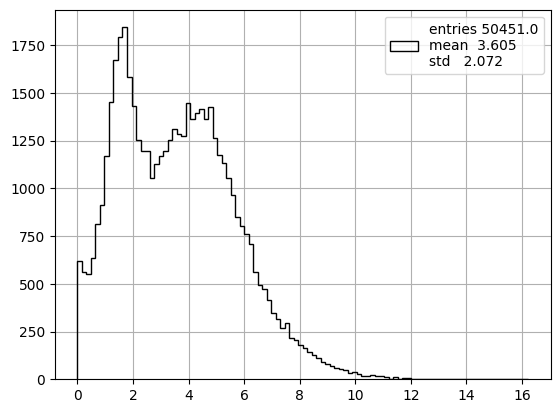

In [5]:
pltext.hist(df_cands.trms.values, 100);

# Greedy nHits

In [8]:
def nHits_greedy_sim(hit_times, hit_pmts, hit_parents,
                     w=20, thresh_min=2, thresh_max=None, jump=0):
    """
    Greedy nHits trigger on a single event from simulation.
    Returns list of candidates, each a dict with indices, times, pmts, parents.
    """
    if len(hit_times) == 0:
        return []

    sort_idx = np.argsort(hit_times)
    ht   = hit_times[sort_idx]
    hpmt = hit_pmts[sort_idx]
    hpar = hit_parents[sort_idx]
    n    = len(ht)

    ends   = ht + w
    right  = np.searchsorted(ht, ends, side="left")
    counts = right - np.arange(n)

    candidates = []
    last_cluster_end = -np.inf
    i = 0

    while i < n:
        if ht[i] < last_cluster_end + jump:
            i += 1
            continue
        if counts[i] < thresh_min:
            i += 1
            continue
        if thresh_max is not None and counts[i] > thresh_max:
            i += 1
            continue

        seed = ht[i]
        collected_end = right[i]

        while collected_end < n:
            t_last = ht[collected_end - 1]
            next_end = np.searchsorted(ht, t_last + w, side="left")
            if next_end > collected_end:
                collected_end = next_end
            else:
                break

        idx = sort_idx[i:collected_end]
        candidates.append({
            "hit_indices" : idx,
            "hit_times"   : ht[i:collected_end],
            "hit_pmts"    : hpmt[i:collected_end],
            "hit_parents" : hpar[i:collected_end],
            "seed_time"   : seed,
            "nhits"       : collected_end - i,
            "trms"        : np.std(ht[i:collected_end]),
            "tc"          : (ht[i:collected_end] - ht[i]).mean(),
            "duration"    : ht[collected_end-1] - ht[i],
        })

        last_cluster_end = ht[collected_end - 1]
        i = collected_end

    return candidates


# --- Run trigger on all events ---
all_candidates = []
global_cand_id = 0

for event_id, event_df in tqdm(df_trueHits_1767.groupby("event_id"), 
                                total=df_trueHits_1767["event_id"].nunique()):
    
    ht   = event_df["true_hit_time"].values
    hpmt = event_df["true_hit_pmt"].values
    hpar = event_df["true_hit_parent"].values
    
    candidates = nHits_greedy_sim(ht, hpmt, hpar, w=20, thresh_min=2)
    
    for cand in candidates:
        cand["event_id"]     = event_id
        cand["candidate_id"] = global_cand_id
        global_cand_id += 1
    
    all_candidates.extend(candidates)

print(f"Total candidates: {len(all_candidates)}")

# --- Summary DataFrame: all parents stored as list ---
df_cands = pd.DataFrame([{
    "event_id"     : c["event_id"],
    "candidate_id" : c["candidate_id"],
    "nhits"        : c["nhits"],
    "trms"         : c["trms"],
    "tc"           : c["tc"],
    "duration"     : c["duration"],
    "seed_time"    : c["seed_time"],
    "all_parents"  : list(np.unique(c["hit_parents"])),
    "all_pmts"     : list(np.unique(c["hit_pmts"])),
    "all_times"    : list(c["hit_times"]),
} for c in all_candidates])

  0%|          | 0/14943 [00:00<?, ?it/s]

Total candidates: 50451


In [9]:
# --- Propagate gamma type to each candidate ---

candidate_types = []

for event_id in tqdm(df_cands["event_id"].unique(), total=df_cands["event_id"].nunique()):
    
    ev_tracks = df_tracks_1767[df_tracks_1767["event_id"] == event_id]
    ev_cands  = df_cands[df_cands["event_id"] == event_id]
    
    # Build electron_id → gamma type mapping for this event
    # Step 1: get all nCapture gammas with their type
    gammas = ev_tracks[(ev_tracks["track_pid"] == 22) & 
                       (ev_tracks["track_creator_process"] == "nCapture")]
    gamma_type = dict(zip(gammas["track_id"], gammas["type"]))
    
    # Step 2: for each electron, find its parent gamma's type
    electrons = ev_tracks[ev_tracks["track_pid"].isin([11, -11])]
    electron_type = {}
    for _, row in electrons.iterrows():
        if row["track_parent"] in gamma_type:
            electron_type[row["track_id"]] = gamma_type[row["track_parent"]]
    
    # Step 3: for each candidate, collect types from its parents (electrons)
    for _, cand in ev_cands.iterrows():
        types = [electron_type.get(p) for p in cand["all_parents"]]
        types_clean = [t for t in types if t is not None]
        
        has_H  = "H" in types_clean
        has_Ni = "Ni" in types_clean
        
        if has_H and not has_Ni:
            ctype = "H"
        elif has_Ni and not has_H:
            ctype = "Ni"
        elif has_H and has_Ni:
            ctype = "mixed"
        else:
            ctype = "unknown"
        
        candidate_types.append({
            "candidate_id"  : cand["candidate_id"],
            "capture_type"  : ctype,
            "gamma_types"   : types_clean,
        })

df_ctypes = pd.DataFrame(candidate_types)
df_cands = df_cands.merge(df_ctypes[["candidate_id", "capture_type"]], on="candidate_id")

print(df_cands["capture_type"].value_counts())

  0%|          | 0/14915 [00:00<?, ?it/s]

capture_type
H          44531
Ni          4974
unknown      786
mixed        160
Name: count, dtype: int64


In [10]:
df_cands["n_parents"] = df_cands["all_parents"].apply(len)

In [11]:
trms_H = df_cands[df_cands["capture_type"].values == "H"]["trms"]
trms_N = df_cands[df_cands["capture_type"].values == "Ni"]["trms"]

In [12]:
trms_single_H = df_cands[(df_cands["capture_type"].values == "H") & (df_cands["n_parents"].values == 1)]["trms"]
trms_single_N = df_cands[(df_cands["capture_type"].values == "Ni") & (df_cands["n_parents"].values == 1)]["trms"]

trms_varios_H = df_cands[(df_cands["capture_type"].values == "H") & (df_cands["n_parents"].values > 1)]["trms"]
trms_varios_N = df_cands[(df_cands["capture_type"].values == "Ni") & (df_cands["n_parents"].values > 1)]["trms"]

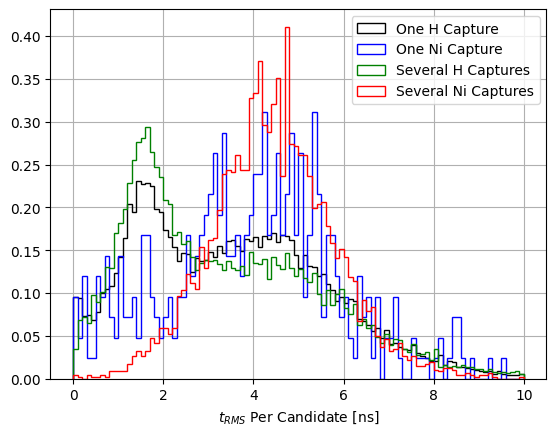

In [13]:
pltext.hist(trms_single_H, 100, density=True, range=(0,10), stats=False, xylabels="$t_{RMS}$ Per Candidate [ns]", label="One H Capture");
pltext.hist(trms_single_N, 100, density=True, range=(0,10), stats=False, xylabels="$t_{RMS}$ Per Candidate [ns]", label="One Ni Capture");
pltext.hist(trms_varios_H, 100, density=True, range=(0,10), stats=False, xylabels="$t_{RMS}$ Per Candidate [ns]", label="Several H Captures");
pltext.hist(trms_varios_N, 100, density=True, range=(0,10), stats=False, xylabels="$t_{RMS}$ Per Candidate [ns]", label="Several Ni Captures");

# H Bump Investigation

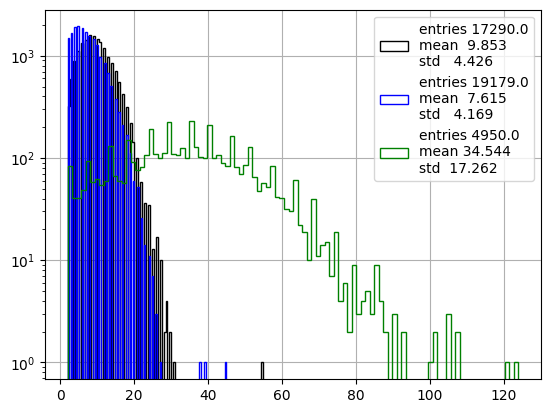

In [ ]:
pltext.hist(df_cands[(df_cands["capture_type"].values == "H") & (df_cands["trms"].values > 3) & (df_cands["trms"].values < 6)]["nhits"].values, 100, ylog=True);
pltext.hist(df_cands[(df_cands["capture_type"].values == "H") & (df_cands["trms"].values < 3)]["nhits"].values,                                 100, ylog=True);
pltext.hist(df_cands[(df_cands["capture_type"].values == "Ni")]["nhits"].values,                                                                100, ylog=True);

# tRMS vs. 

In [47]:
from matplotlib.backends.backend_pdf import PdfPages
import os

os.makedirs("./files", exist_ok=True)

n_events = 100
event_ids = df_cands["event_id"].unique()[:n_events]

# --- Tank geometry ---
R_tank = 150   # cm
Y_bot  = -150  # cm
Y_top  =  150  # cm
source = (0, 80, 0)

with PdfPages("./files/tRMS_bump_investigation_MC.pdf") as pdf:
    
    for event_id in tqdm(event_ids, total=len(event_ids)):
        
        fig = plt.figure(figsize=(20, 10))
        
        # =============================================
        # LEFT: 3D plot
        # =============================================
        ax3d = fig.add_subplot(121, projection='3d')
        
        # Get Cherenkov vertices
        ev_cands = df_cands[df_cands["event_id"] == event_id]
        if len(ev_cands) == 0:
            plt.close(fig)
            continue
        
        electrons = np.concatenate(ev_cands["all_parents"].to_numpy())
        cher_tracks = df_tracks_1767[
            (df_tracks_1767["event_id"] == event_id) & 
            (df_tracks_1767["track_id"].isin(electrons))
        ]
        
        if len(cher_tracks) == 0:
            plt.close(fig)
            continue
        
        x = cher_tracks["track_xi"].values.astype(np.float64)
        y = cher_tracks["track_yi"].values.astype(np.float64)
        z = cher_tracks["track_zi"].values.astype(np.float64)
        
        # Classify vertices
        ev_tracks = df_tracks_1767[df_tracks_1767["event_id"] == event_id]
        gammas_ev = ev_tracks[(ev_tracks["track_pid"] == 22) & 
                               (ev_tracks["track_creator_process"] == "nCapture")]
        gamma_type = dict(zip(gammas_ev["track_id"], gammas_ev["type"]))
        
        electron_capture = {}
        for _, row in ev_tracks[ev_tracks["track_pid"].isin([11, -11])].iterrows():
            if row["track_parent"] in gamma_type:
                electron_capture[row["track_id"]] = gamma_type[row["track_parent"]]
        
        vertex_types = np.array([electron_capture.get(tid, "unknown") for tid in cher_tracks["track_id"].values])
        mask_H_3d  = vertex_types == "H"
        mask_Ni_3d = vertex_types == "Ni"
        mask_unk   = ~(mask_H_3d | mask_Ni_3d)
        
        theta_cyl = np.linspace(0, 2*np.pi, 60)
        
        # Barrel vertical lines
        for angle in np.linspace(0, 2*np.pi, 24, endpoint=False):
            ax3d.plot([R_tank*np.cos(angle)]*2, 
                      [R_tank*np.sin(angle)]*2,
                      [Y_bot, Y_top], color='gray', alpha=0.2, linewidth=0.5)
        
        # Top and bottom circles
        for y_cap in [Y_bot, Y_top]:
            ax3d.plot(R_tank * np.cos(theta_cyl), 
                      R_tank * np.sin(theta_cyl),
                      y_cap * np.ones_like(theta_cyl), color='gray', alpha=0.4, linewidth=1)
        
        # NiCf source sphere
        R_source = 6.75
        u_sph = np.linspace(0, 2*np.pi, 30)
        v_sph = np.linspace(0, np.pi, 20)
        x_sph = source[0] + R_source * np.outer(np.cos(u_sph), np.sin(v_sph))
        y_sph = source[1] + R_source * np.outer(np.ones_like(u_sph), np.cos(v_sph))
        z_sph = source[2] + R_source * np.outer(np.sin(u_sph), np.sin(v_sph))
        ax3d.plot_wireframe(x_sph, z_sph, y_sph, color='orange', alpha=0.4, linewidth=0.5)
        
        # Origin
        ax3d.scatter([0], [0], [0], color='green', s=100, marker='x', linewidths=2, zorder=10)
        
        # Vertices (swap y<->z for vertical display)
        if mask_H_3d.sum() > 0:
            ax3d.scatter(x[mask_H_3d], z[mask_H_3d], y[mask_H_3d], s=12, color='blue', alpha=0.6, label=f'H ({mask_H_3d.sum()})')
        if mask_Ni_3d.sum() > 0:
            ax3d.scatter(x[mask_Ni_3d], z[mask_Ni_3d], y[mask_Ni_3d], s=12, color='red', alpha=0.6, label=f'Ni ({mask_Ni_3d.sum()})')
        if mask_unk.sum() > 0:
            ax3d.scatter(x[mask_unk], z[mask_unk], y[mask_unk], s=4, color='gray', alpha=0.3, label=f'Unk ({mask_unk.sum()})')
        
        ax3d.set_xlabel("x [cm]")
        ax3d.set_ylabel("z [cm]")
        ax3d.set_zlabel("y [cm] (vertical)")
        ax3d.set_title(f"Event {event_id}: Cherenkov vertices")
        ax3d.legend(loc='upper left', fontsize=7)
        
        # =============================================
        # RIGHT: dwall vs tRMS
        # =============================================
        ax2d = fig.add_subplot(122)
        
        dwall_list = []
        trms_list  = []
        ctype_list = []
        npar_list  = []
        nhits_list = []
        
        for _, cand in ev_cands.iterrows():
            for parent_id in cand["all_parents"]:
                trk = ev_tracks[ev_tracks["track_id"] == parent_id]
                if len(trk) == 0:
                    continue
                
                row = trk.iloc[0]
                xi, yi, zi = float(row["track_xi"]), float(row["track_yi"]), float(row["track_zi"])
                r = np.sqrt(xi**2 + zi**2)
                
                d_barrel = R_tank - r
                d_top    = Y_top - yi
                d_bot    = yi - Y_bot
                d_wall   = min(d_barrel, d_top, d_bot)
                
                dwall_list.append(d_wall)
                trms_list.append(cand["trms"])
                ctype_list.append(cand["capture_type"])
                npar_list.append(cand["n_parents"])
                nhits_list.append(cand["nhits"])
        
        if len(dwall_list) > 0:
            dwall = np.array(dwall_list)
            trms  = np.array(trms_list)
            ctype = np.array(ctype_list)
            npar  = np.array(npar_list)
            nhits = np.array(nhits_list)
            
            mask_H  = ctype == "H"
            mask_Ni = ctype == "Ni"
            
            if mask_H.sum() > 0:
                ax2d.scatter(dwall[mask_H], trms[mask_H], s=20, color='blue', alpha=0.6, label=f'H ({mask_H.sum()})')
            if mask_Ni.sum() > 0:
                ax2d.scatter(dwall[mask_Ni], trms[mask_Ni], s=20, color='red', alpha=0.6, label=f'Ni ({mask_Ni.sum()})')
            
            for i in range(len(dwall)):
                ax2d.annotate(f"({npar[i]}, {nhits[i]})", (dwall[i], trms[i]),
                              textcoords="offset points", xytext=(0, 6),
                              fontsize=7, ha='center', color='black')
        
        ax2d.set_xlabel("Distance to nearest wall [cm]")
        ax2d.set_ylabel("$t_{RMS}$ of candidate [ns]")
        ax2d.set_ylim(0,10)
        ax2d.set_xlim(0,150)
        ax2d.set_title(f"Event {event_id}: dwall vs tRMS")
        ax2d.legend(fontsize=8)
        ax2d.grid(True)
        
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved {len(event_ids)} pages to ./files/tRMS_bump_investigation_MC.pdf")

  0%|          | 0/100 [00:00<?, ?it/s]

Saved 100 pages to ./files/tRMS_bump_investigation_MC.pdf


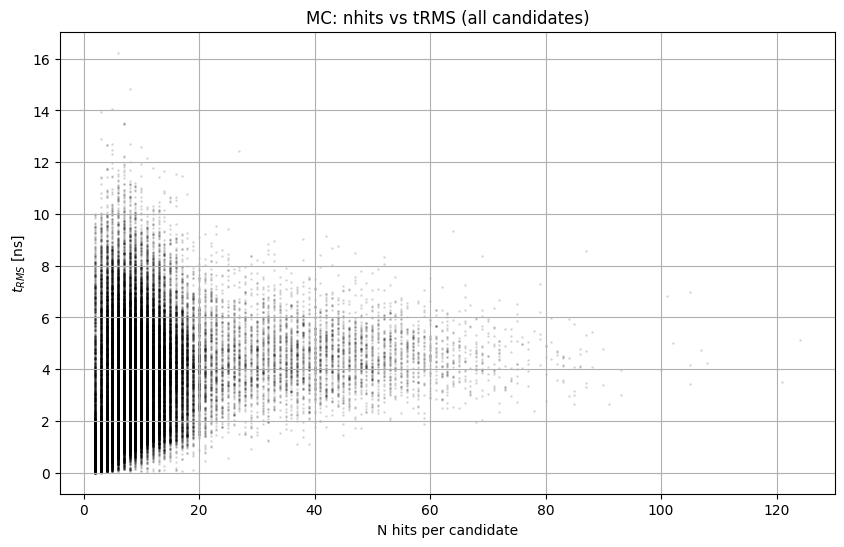

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_cands["nhits"], df_cands["trms"], s=1, alpha=0.1, color='black')
ax.set_xlabel("N hits per candidate")
ax.set_ylabel("$t_{RMS}$ [ns]")
ax.set_title("MC: nhits vs tRMS (all candidates)")
ax.grid(True)
plt.show()

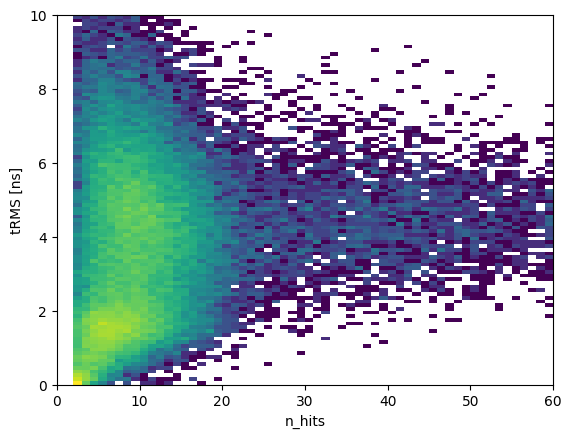

In [50]:
plt.hist2d(df_cands["nhits"], df_cands["trms"], (60,100), norm="log", range=((0, 60), (0,10)));
plt.xlabel("n_hits");
plt.ylabel("tRMS [ns]");

In [51]:
df_cands[df_cands["event_id"].values == 9]

,event_id,candidate_id,nhits,trms,tc,duration,seed_time,all_parents,all_pmts,all_times,capture_type,n_parents
24,9,24,6,2.560250,3.486735,6.476562,2951.214355,"[97, 98]","[142, 143, 1361, 1370, 1577, 1578]","[2951.2144, 2951.4277, 2955.076, 2955.5007, 29...",H,2
25,9,25,36,4.713386,4.921115,18.914062,41206.058594,"[37, 38, 39, 55]","[34, 43, 68, 81, 159, 359, 391, 400, 604, 1127...","[41206.06, 41206.133, 41206.344, 41206.35, 412...",Ni,4
26,9,26,60,5.282441,5.775391,25.296875,112558.398438,"[123, 125, 136, 148]","[155, 160, 182, 189, 221, 236, 238, 254, 266, ...","[112558.4, 112558.41, 112558.484, 112558.52, 1...",Ni,4


# ToF Correction

  0%|          | 0/14915 [00:00<?, ?it/s]

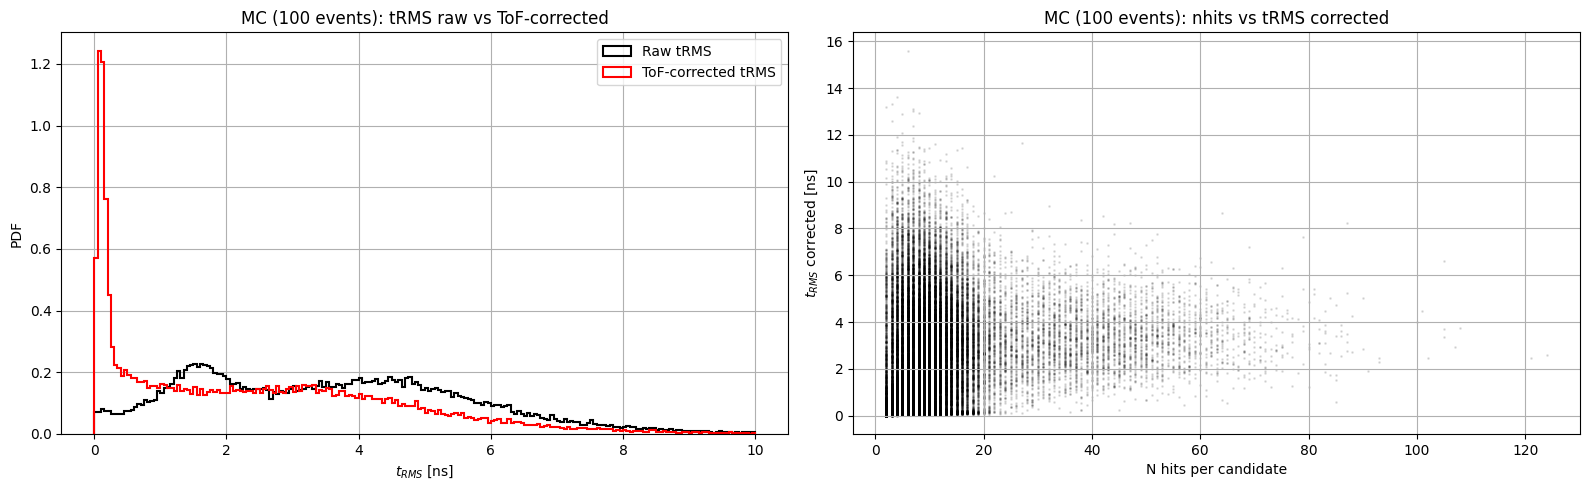

Mean tRMS raw:       3.605 ns
Mean tRMS corrected: 2.409 ns


In [14]:
c_water = 21.77  # cm/ns

event_ids_100 = df_cands["event_id"].unique()
df_cands_100  = df_cands[df_cands["event_id"].isin(event_ids_100)].copy()

all_corrected_times = []
all_trms_corrected  = []

for event_id in tqdm(event_ids_100, total=len(event_ids_100)):
    
    ev_tracks = df_tracks_1767[df_tracks_1767["event_id"] == event_id]
    ev_hits   = df_trueHits_1767[df_trueHits_1767["event_id"] == event_id]
    ev_cands  = df_cands_100[df_cands_100["event_id"] == event_id]
    
    # Build parent_id → (vx, vy, vz)
    vertex_map = {}
    for _, row in ev_tracks[ev_tracks["track_pid"].isin([11, -11])].iterrows():
        vertex_map[row["track_id"]] = (float(row["track_xi"]), 
                                        float(row["track_yi"]), 
                                        float(row["track_zi"]))
    
    # Precompute hit arrays
    hit_times   = ev_hits["true_hit_time"].values
    hit_parents = ev_hits["true_hit_parent"].values
    hit_x       = ev_hits["hit_x"].values.astype(np.float64)
    hit_y       = ev_hits["hit_y"].values.astype(np.float64)
    hit_z       = ev_hits["hit_z"].values.astype(np.float64)
    
    # Precompute ToF for every hit in this event
    tof_corrections = np.full(len(ev_hits), np.nan)
    for i in range(len(ev_hits)):
        pid = hit_parents[i]
        if pid in vertex_map:
            vx, vy, vz = vertex_map[pid]
            dist = np.sqrt((hit_x[i] - vx)**2 + (hit_y[i] - vy)**2 + (hit_z[i] - vz)**2)
            tof_corrections[i] = dist / c_water
    
    corrected_hit_times = hit_times - tof_corrections
    
    # For each candidate, grab its hits and compute tRMS_corrected
    for _, cand in ev_cands.iterrows():
        cand_times = np.array(cand["all_times"])
        
        cand_corr = []
        for t in cand_times:
            idx = np.argmin(np.abs(hit_times - t))
            if np.abs(hit_times[idx] - t) < 1e-3:
                cand_corr.append(corrected_hit_times[idx])
        
        cand_corr = np.array(cand_corr)
        valid = ~np.isnan(cand_corr)
        
        if valid.sum() > 1:
            all_corrected_times.append(list(cand_corr[valid]))
            all_trms_corrected.append(np.std(cand_corr[valid]))
        else:
            all_corrected_times.append([])
            all_trms_corrected.append(np.nan)

df_cands_100["tof_corrected_times"] = all_corrected_times
df_cands_100["trms_corrected"]      = all_trms_corrected

# --- Compare ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_cands_100["trms"], bins=200, range=(0, 10), density=True,
             histtype='step', color='black', linewidth=1.5, label='Raw tRMS')
axes[0].hist(df_cands_100["trms_corrected"].dropna(), bins=200, range=(0, 10), density=True,
             histtype='step', color='red', linewidth=1.5, label='ToF-corrected tRMS')
axes[0].set_xlabel("$t_{RMS}$ [ns]")
axes[0].set_ylabel("PDF")
axes[0].set_title("MC (100 events): tRMS raw vs ToF-corrected")
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(df_cands_100["nhits"], df_cands_100["trms_corrected"], s=1, alpha=0.1, color='black')
axes[1].set_xlabel("N hits per candidate")
axes[1].set_ylabel("$t_{RMS}$ corrected [ns]")
axes[1].set_title("MC (100 events): nhits vs tRMS corrected")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Mean tRMS raw:       {df_cands_100['trms'].mean():.3f} ns")
print(f"Mean tRMS corrected: {df_cands_100['trms_corrected'].mean():.3f} ns")

  0%|          | 0/14915 [00:00<?, ?it/s]

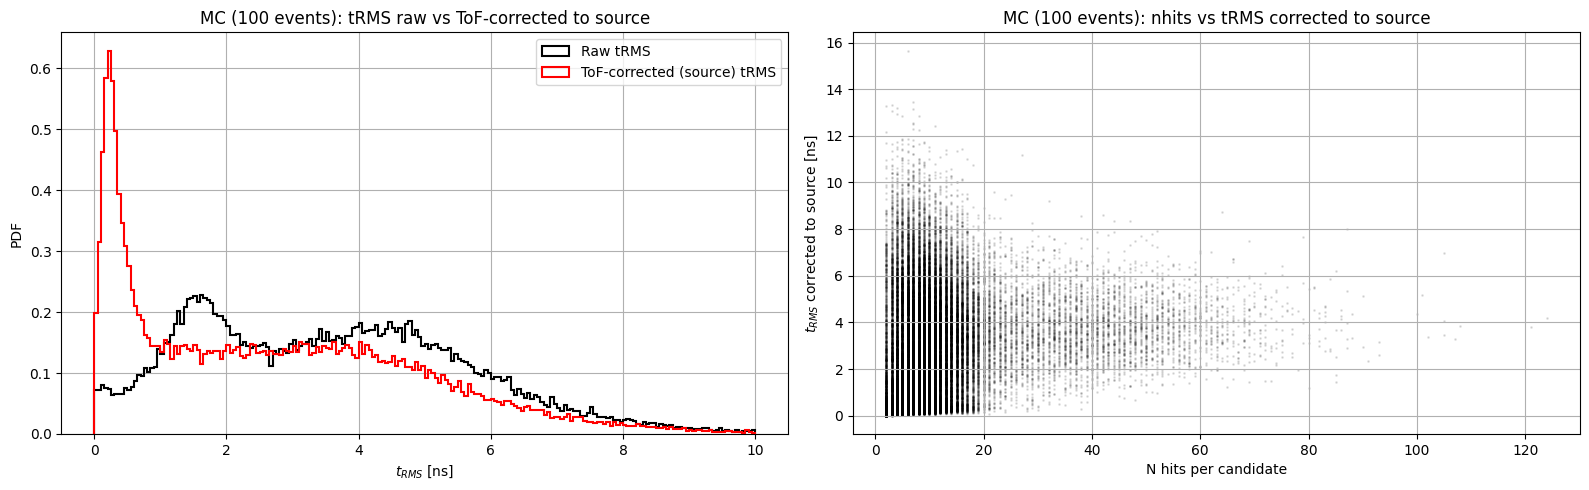

Mean tRMS raw:              3.605 ns
Mean tRMS corrected source: 2.720 ns


In [15]:
c_water = 21.77  # cm/ns
source = (0, 80, 0)

event_ids_100 = df_cands["event_id"].unique()
df_cands_100  = df_cands[df_cands["event_id"].isin(event_ids_100)].copy()

all_corrected_times_source = []
all_trms_corrected_source  = []

for event_id in tqdm(event_ids_100, total=len(event_ids_100)):
    
    ev_hits  = df_trueHits_1767[df_trueHits_1767["event_id"] == event_id]
    ev_cands = df_cands_100[df_cands_100["event_id"] == event_id]
    
    hit_times = ev_hits["true_hit_time"].values
    hit_x     = ev_hits["hit_x"].values.astype(np.float64)
    hit_y     = ev_hits["hit_y"].values.astype(np.float64)
    hit_z     = ev_hits["hit_z"].values.astype(np.float64)
    
    # ToF from source to each PMT
    dist_to_source = np.sqrt((hit_x - source[0])**2 + 
                              (hit_y - source[1])**2 + 
                              (hit_z - source[2])**2)
    tof_source = dist_to_source / c_water
    corrected_source = hit_times - tof_source
    
    for _, cand in ev_cands.iterrows():
        cand_times = np.array(cand["all_times"])
        
        cand_corr = []
        for t in cand_times:
            idx = np.argmin(np.abs(hit_times - t))
            if np.abs(hit_times[idx] - t) < 1e-3:
                cand_corr.append(corrected_source[idx])
        
        cand_corr = np.array(cand_corr)
        
        if len(cand_corr) > 1:
            all_corrected_times_source.append(list(cand_corr))
            all_trms_corrected_source.append(np.std(cand_corr))
        else:
            all_corrected_times_source.append([])
            all_trms_corrected_source.append(np.nan)

df_cands_100["tof_corrected_times_source"] = all_corrected_times_source
df_cands_100["trms_corrected_source"]      = all_trms_corrected_source

# --- Compare ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_cands_100["trms"], bins=200, range=(0, 10), density=True,
             histtype='step', color='black', linewidth=1.5, label='Raw tRMS')
axes[0].hist(df_cands_100["trms_corrected_source"].dropna(), bins=200, range=(0, 10), density=True,
             histtype='step', color='red', linewidth=1.5, label='ToF-corrected (source) tRMS')
axes[0].set_xlabel("$t_{RMS}$ [ns]")
axes[0].set_ylabel("PDF")
axes[0].set_title("MC (100 events): tRMS raw vs ToF-corrected to source")
axes[0].legend()
axes[0].grid(True)

axes[1].scatter(df_cands_100["nhits"], df_cands_100["trms_corrected_source"], s=1, alpha=0.1, color='black')
axes[1].set_xlabel("N hits per candidate")
axes[1].set_ylabel("$t_{RMS}$ corrected to source [ns]")
axes[1].set_title("MC (100 events): nhits vs tRMS corrected to source")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Mean tRMS raw:              {df_cands_100['trms'].mean():.3f} ns")
print(f"Mean tRMS corrected source: {df_cands_100['trms_corrected_source'].mean():.3f} ns")

KeyError: 'trms_corrected'

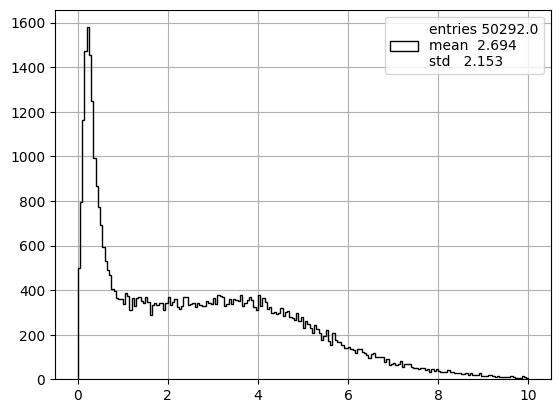

In [17]:
pltext.hist(df_cands_100["trms_corrected_source"].dropna(), bins=200, range=(0, 10));
pltext.hist(df_cands_100["trms_corrected"].dropna(),        bins=200, range=(0, 10));

  0%|          | 0/14915 [00:00<?, ?it/s]

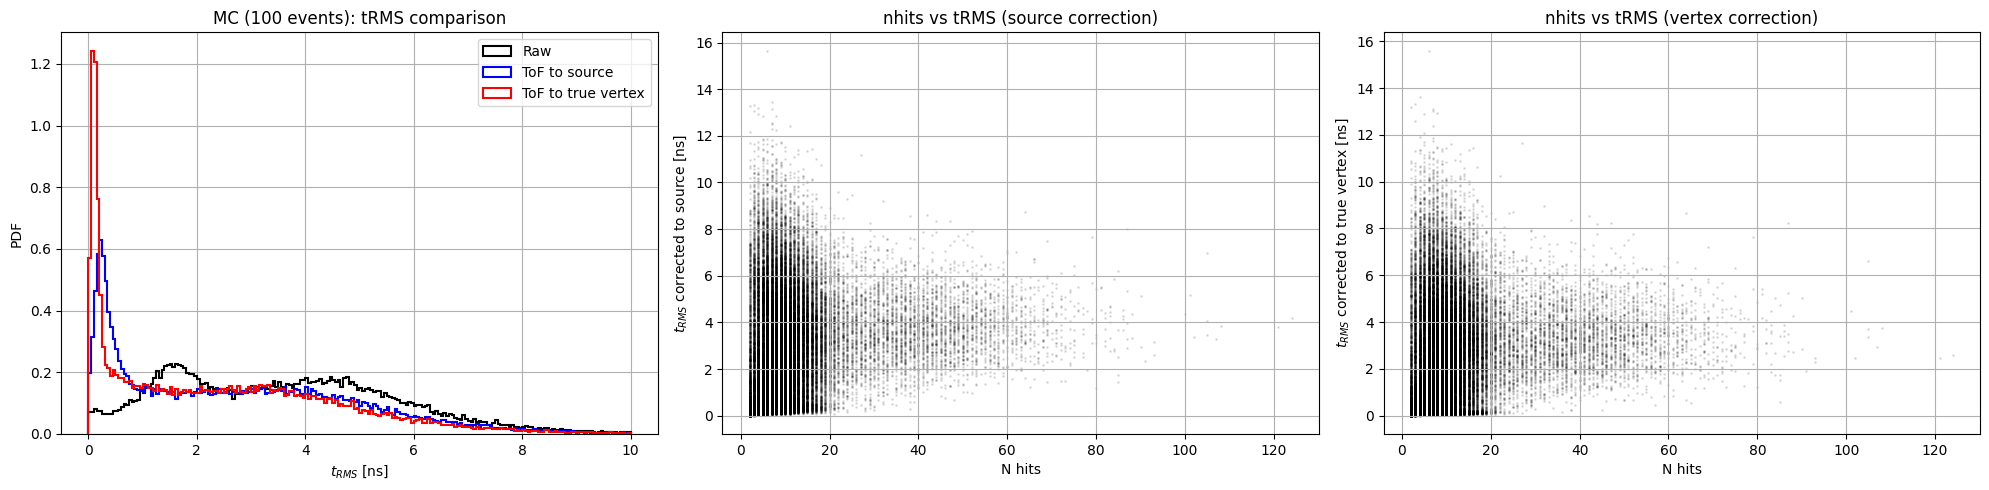

Mean tRMS raw:              3.605 ns
Mean tRMS corrected source: 2.720 ns
Mean tRMS corrected vertex: 2.409 ns


In [19]:
c_water = 21.77  # cm/ns
source = (0, 80, 0)

event_ids_100 = df_cands["event_id"].unique()
df_cands_100  = df_cands[df_cands["event_id"].isin(event_ids_100)].copy()

all_corr_vertex_times = []
all_trms_vertex       = []
all_corr_source_times = []
all_trms_source       = []

for event_id in tqdm(event_ids_100, total=len(event_ids_100)):
    
    ev_tracks = df_tracks_1767[df_tracks_1767["event_id"] == event_id]
    ev_hits   = df_trueHits_1767[df_trueHits_1767["event_id"] == event_id]
    ev_cands  = df_cands_100[df_cands_100["event_id"] == event_id]
    
    # Build parent_id → (vx, vy, vz)
    vertex_map = {}
    for _, row in ev_tracks[ev_tracks["track_pid"].isin([11, -11])].iterrows():
        vertex_map[row["track_id"]] = (float(row["track_xi"]),
                                        float(row["track_yi"]),
                                        float(row["track_zi"]))
    
    # Precompute hit arrays
    hit_times   = ev_hits["true_hit_time"].values
    hit_parents = ev_hits["true_hit_parent"].values
    hit_x       = ev_hits["hit_x"].values.astype(np.float64)
    hit_y       = ev_hits["hit_y"].values.astype(np.float64)
    hit_z       = ev_hits["hit_z"].values.astype(np.float64)
    
    # ToF correction to true vertex (per hit)
    tof_vertex = np.full(len(ev_hits), np.nan)
    for i in range(len(ev_hits)):
        pid = hit_parents[i]
        if pid in vertex_map:
            vx, vy, vz = vertex_map[pid]
            dist = np.sqrt((hit_x[i] - vx)**2 + (hit_y[i] - vy)**2 + (hit_z[i] - vz)**2)
            tof_vertex[i] = dist / c_water
    
    corrected_vertex = hit_times - tof_vertex
    
    # ToF correction to source (all hits to same point)
    dist_source = np.sqrt((hit_x - source[0])**2 +
                           (hit_y - source[1])**2 +
                           (hit_z - source[2])**2)
    tof_source = dist_source / c_water
    corrected_source = hit_times - tof_source
    
    # For each candidate
    for _, cand in ev_cands.iterrows():
        cand_times = np.array(cand["all_times"])
        
        cand_corr_vertex = []
        cand_corr_source = []
        
        for t in cand_times:
            idx = np.argmin(np.abs(hit_times - t))
            if np.abs(hit_times[idx] - t) < 1e-3:
                cand_corr_vertex.append(corrected_vertex[idx])
                cand_corr_source.append(corrected_source[idx])
        
        cand_corr_vertex = np.array(cand_corr_vertex)
        cand_corr_source = np.array(cand_corr_source)
        
        valid_v = ~np.isnan(cand_corr_vertex)
        valid_s = ~np.isnan(cand_corr_source)
        
        if valid_v.sum() > 1:
            all_corr_vertex_times.append(list(cand_corr_vertex[valid_v]))
            all_trms_vertex.append(np.std(cand_corr_vertex[valid_v]))
        else:
            all_corr_vertex_times.append([])
            all_trms_vertex.append(np.nan)
        
        if valid_s.sum() > 1:
            all_corr_source_times.append(list(cand_corr_source[valid_s]))
            all_trms_source.append(np.std(cand_corr_source[valid_s]))
        else:
            all_corr_source_times.append([])
            all_trms_source.append(np.nan)

df_cands_100["tof_corrected_vertex_times"] = all_corr_vertex_times
df_cands_100["trms_corrected_vertex"]      = all_trms_vertex
df_cands_100["tof_corrected_source_times"] = all_corr_source_times
df_cands_100["trms_corrected_source"]      = all_trms_source

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# tRMS comparison
axes[0].hist(df_cands_100["trms"], bins=200, range=(0, 10), density=True,
             histtype='step', color='black', linewidth=1.5, label='Raw')
axes[0].hist(df_cands_100["trms_corrected_source"].dropna(), bins=200, range=(0, 10), density=True,
             histtype='step', color='blue', linewidth=1.5, label='ToF to source')
axes[0].hist(df_cands_100["trms_corrected_vertex"].dropna(), bins=200, range=(0, 10), density=True,
             histtype='step', color='red', linewidth=1.5, label='ToF to true vertex')
axes[0].set_xlabel("$t_{RMS}$ [ns]")
axes[0].set_ylabel("PDF")
axes[0].set_title("MC (100 events): tRMS comparison")
axes[0].legend()
axes[0].grid(True)

# nhits vs tRMS corrected to source
axes[1].scatter(df_cands_100["nhits"], df_cands_100["trms_corrected_source"], 
                s=1, alpha=0.1, color='black')
axes[1].set_xlabel("N hits")
axes[1].set_ylabel("$t_{RMS}$ corrected to source [ns]")
axes[1].set_title("nhits vs tRMS (source correction)")
axes[1].grid(True)

# nhits vs tRMS corrected to true vertex
axes[2].scatter(df_cands_100["nhits"], df_cands_100["trms_corrected_vertex"],
                s=1, alpha=0.1, color='black')
axes[2].set_xlabel("N hits")
axes[2].set_ylabel("$t_{RMS}$ corrected to true vertex [ns]")
axes[2].set_title("nhits vs tRMS (vertex correction)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Mean tRMS raw:              {df_cands_100['trms'].mean():.3f} ns")
print(f"Mean tRMS corrected source: {df_cands_100['trms_corrected_source'].mean():.3f} ns")
print(f"Mean tRMS corrected vertex: {df_cands_100['trms_corrected_vertex'].mean():.3f} ns")

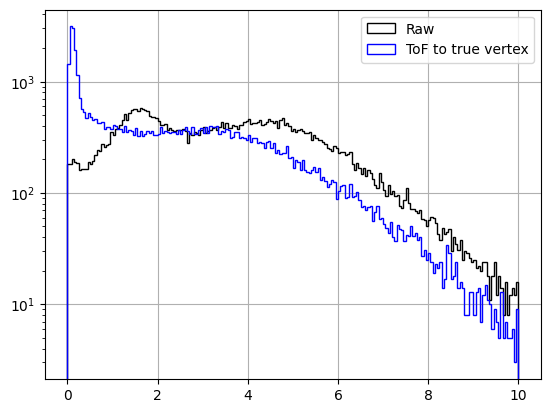

In [ ]:
pltext.hist(df_cands_100["trms"],                           bins=200, ylog=True, stats=False, range=(0, 10), label='Raw');
pltext.hist(df_cands_100["trms_corrected_vertex"].dropna(), bins=200, ylog=True, stats=False, range=(0, 10), label='ToF to true vertex');
pltext.hist(df_cands_100["trms_corrected_source"].dropna(), bins=200, ylog=False, stats=False, range=(0, 10), label='ToF to source');

In [1]:
pltext.hist(df_cands_100["trms_corrected_vertex"].dropna(),                                             200, density=True, range=(0,10));
pltext.hist(df_cands_100[df_cands_100["capture_type"].values == "H"]["trms_corrected_vertex"].dropna(), 200, density=True, range=(0,10));
pltext.hist(df_cands_100[df_cands_100["capture_type"].values == "H"]["trms_corrected_source"].dropna(), 200, density=True, range=(0,10));

NameError: name 'pltext' is not defined

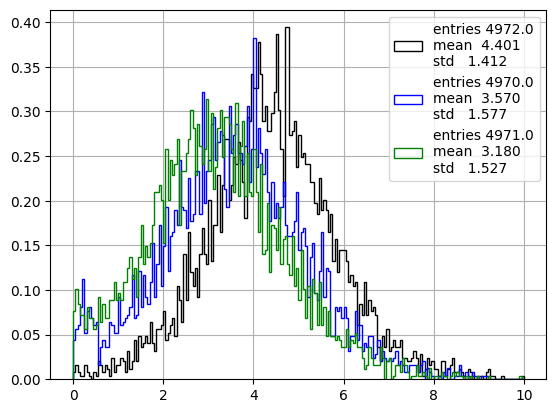

In [45]:
pltext.hist(df_cands_100[df_cands_100["capture_type"].values == "Ni"]["trms"].dropna(), 200, density=True, range=(0,10));
pltext.hist(df_cands_100[df_cands_100["capture_type"].values == "Ni"]["trms_corrected_source"].dropna(), 200, density=True, range=(0,10));
pltext.hist(df_cands_100[df_cands_100["capture_type"].values == "Ni"]["trms_corrected_vertex"].dropna(), 200, density=True, range=(0,10));

In [46]:
df_cands_100.to_csv("files/candidates_df_tofCorr.csv")

  0%|          | 0/14915 [00:00<?, ?it/s]

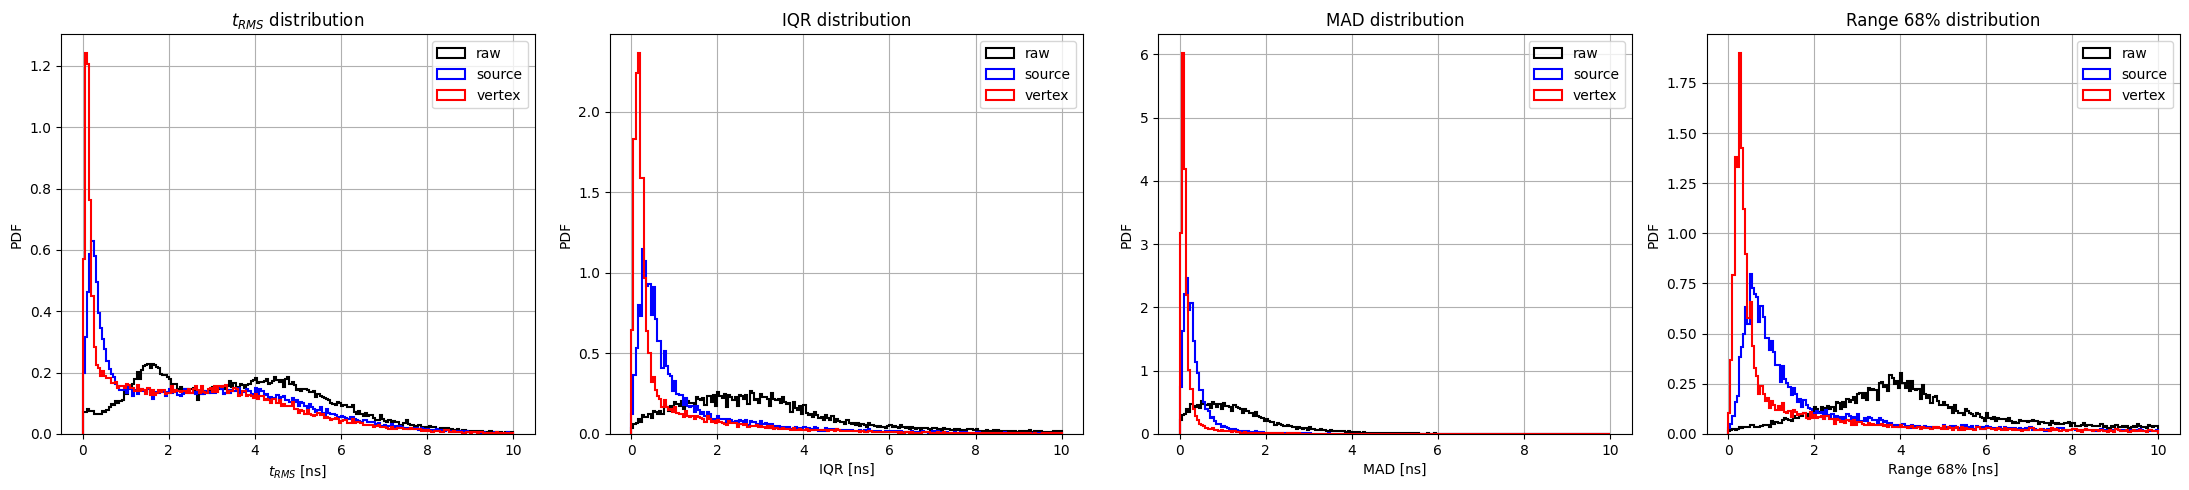

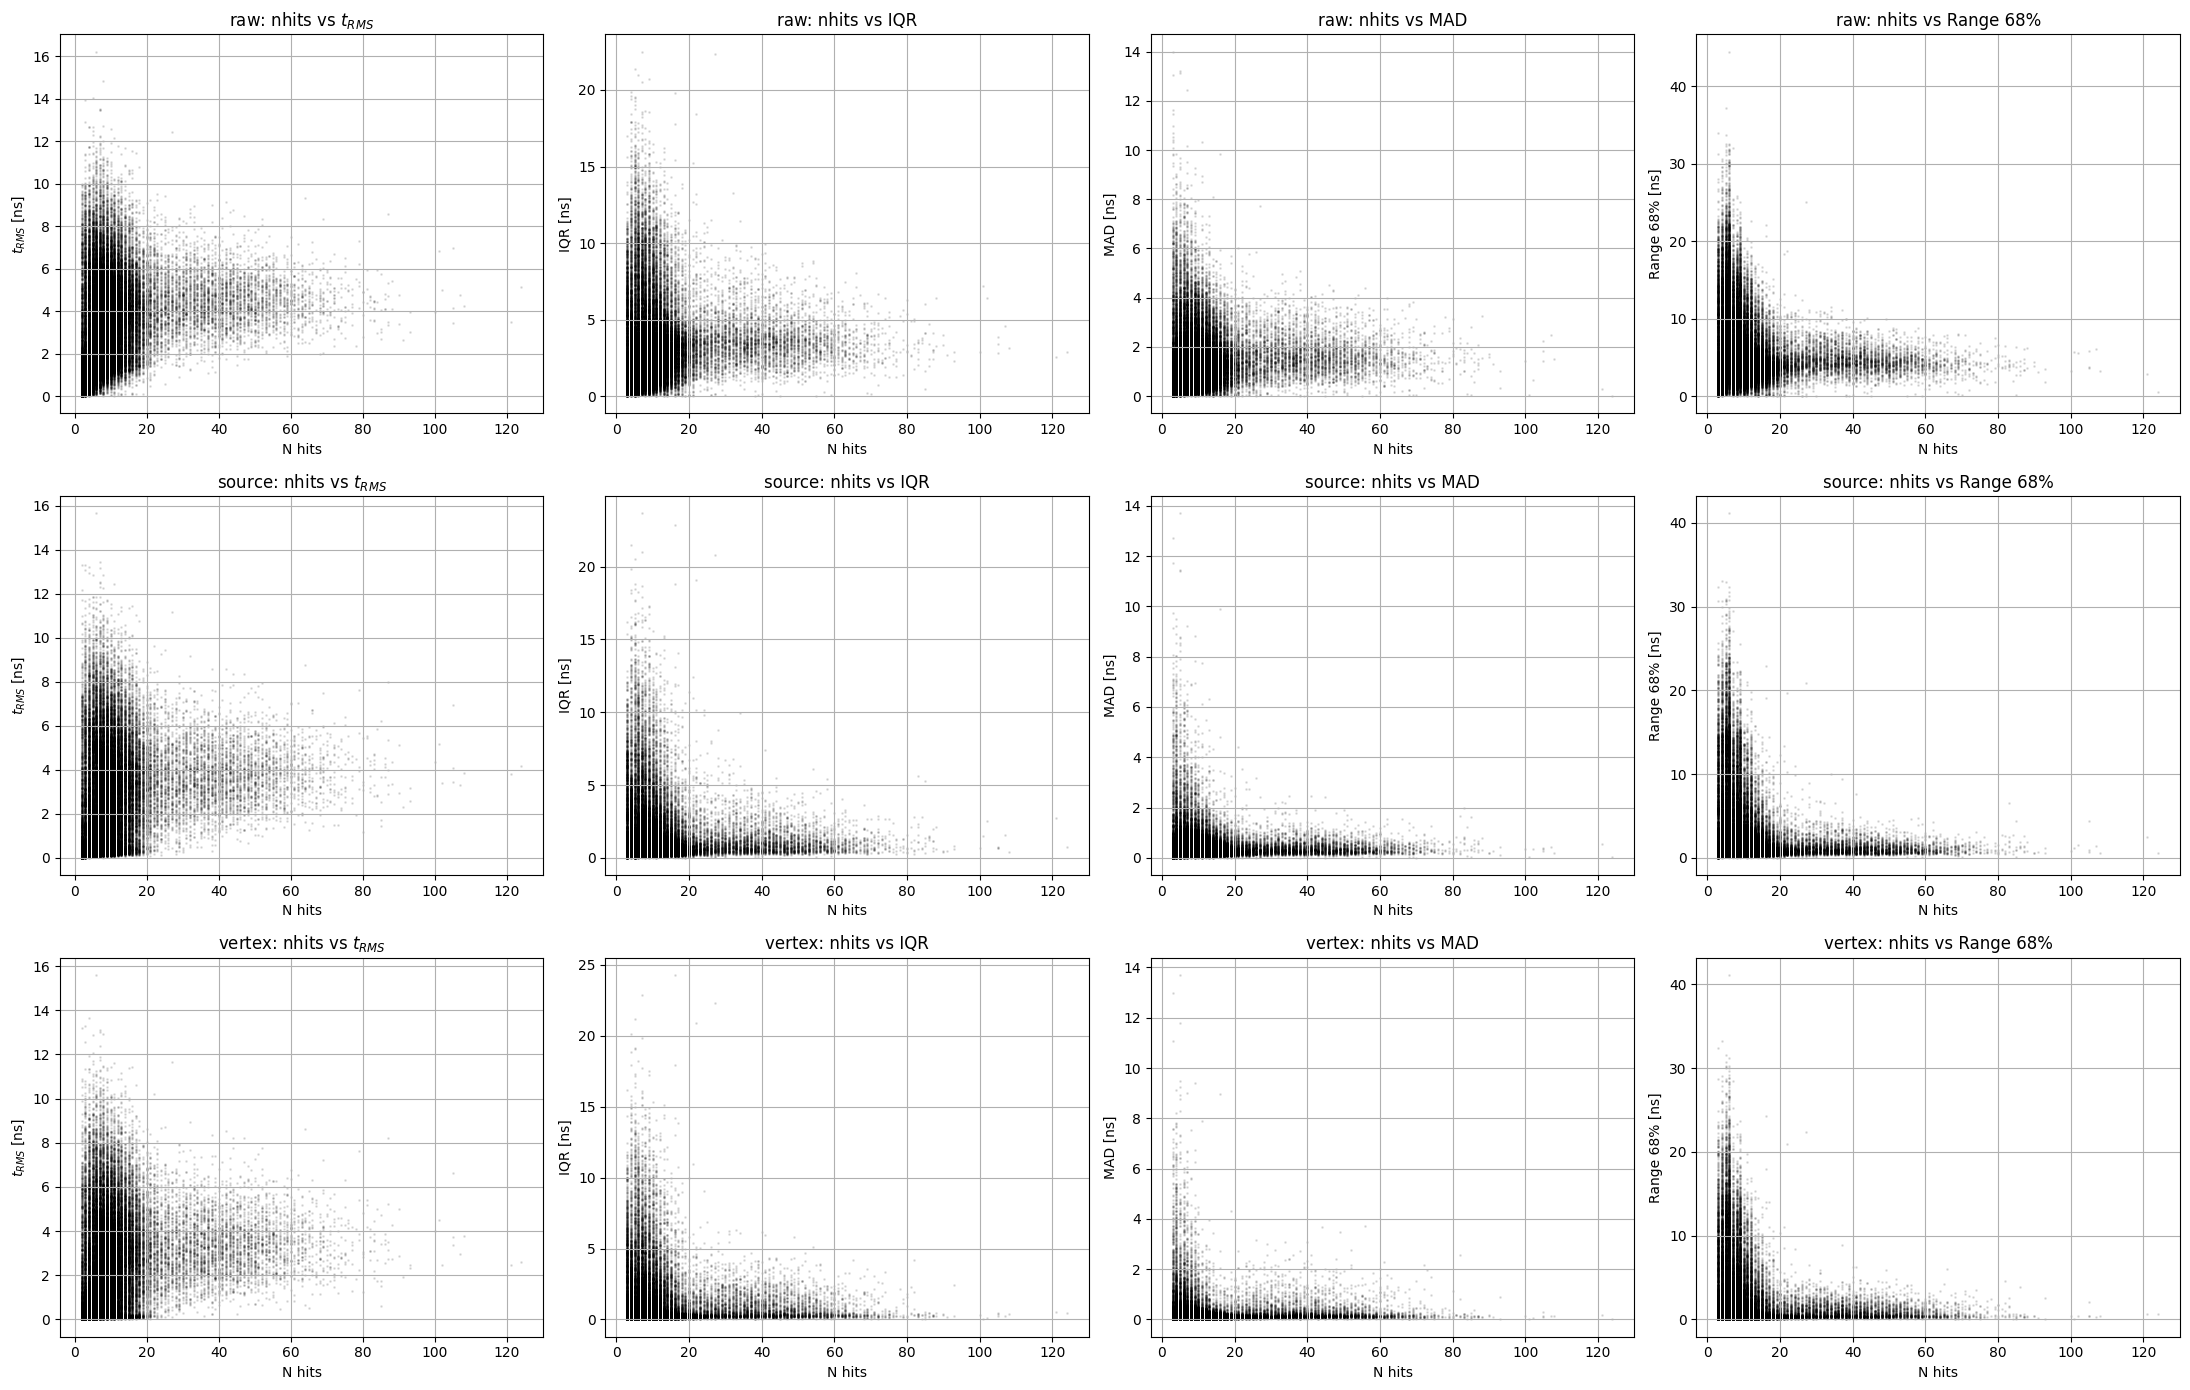

In [15]:
c_water = 21.77  # cm/ns
source = (0, 80, 0)

def robust_estimators(times):
    if len(times) < 3:
        return np.nan, np.nan, np.nan
    t = np.sort(times)
    n = len(t)
    
    iqr = np.percentile(t, 75) - np.percentile(t, 25)
    mad = np.median(np.abs(t - np.median(t)))
    
    w = int(np.ceil(0.68 * n))
    if w >= n:
        r68 = t[-1] - t[0]
    else:
        ranges = t[w:] - t[:n-w]
        r68 = ranges.min()
    
    return iqr, mad, r68

event_ids_100 = df_cands["event_id"].unique()
df_cands_100  = df_cands[df_cands["event_id"].isin(event_ids_100)].copy()

results = {key: [] for key in [
    "corr_vertex_times", "trms_vertex", "iqr_vertex", "mad_vertex", "r68_vertex",
    "corr_source_times", "trms_source", "iqr_source", "mad_source", "r68_source",
    "iqr_raw", "mad_raw", "r68_raw",
]}

for event_id in tqdm(event_ids_100, total=len(event_ids_100)):
    
    ev_tracks = df_tracks_1767[df_tracks_1767["event_id"] == event_id]
    ev_hits   = df_trueHits_1767[df_trueHits_1767["event_id"] == event_id]
    ev_cands  = df_cands_100[df_cands_100["event_id"] == event_id]
    
    # Build parent_id → (vx, vy, vz)
    vertex_map = {}
    for _, row in ev_tracks[ev_tracks["track_pid"].isin([11, -11])].iterrows():
        vertex_map[row["track_id"]] = (float(row["track_xi"]),
                                        float(row["track_yi"]),
                                        float(row["track_zi"]))
    
    hit_times   = ev_hits["true_hit_time"].values
    hit_parents = ev_hits["true_hit_parent"].values
    hit_x       = ev_hits["hit_x"].values.astype(np.float64)
    hit_y       = ev_hits["hit_y"].values.astype(np.float64)
    hit_z       = ev_hits["hit_z"].values.astype(np.float64)
    
    # ToF to true vertex
    tof_vertex = np.full(len(ev_hits), np.nan)
    for i in range(len(ev_hits)):
        pid = hit_parents[i]
        if pid in vertex_map:
            vx, vy, vz = vertex_map[pid]
            dist = np.sqrt((hit_x[i] - vx)**2 + (hit_y[i] - vy)**2 + (hit_z[i] - vz)**2)
            tof_vertex[i] = dist / c_water
    corrected_vertex = hit_times - tof_vertex
    
    # ToF to source
    dist_source = np.sqrt((hit_x - source[0])**2 +
                           (hit_y - source[1])**2 +
                           (hit_z - source[2])**2)
    corrected_source = hit_times - dist_source / c_water
    
    for _, cand in ev_cands.iterrows():
        cand_times = np.array(cand["all_times"])
        
        cand_corr_vertex = []
        cand_corr_source = []
        
        for t in cand_times:
            idx = np.argmin(np.abs(hit_times - t))
            if np.abs(hit_times[idx] - t) < 1e-3:
                cand_corr_vertex.append(corrected_vertex[idx])
                cand_corr_source.append(corrected_source[idx])
        
        cand_corr_vertex = np.array(cand_corr_vertex)
        cand_corr_source = np.array(cand_corr_source)
        
        valid_v = ~np.isnan(cand_corr_vertex)
        valid_s = ~np.isnan(cand_corr_source)
        
        # Raw
        iqr_r, mad_r, r68_r = robust_estimators(cand_times)
        results["iqr_raw"].append(iqr_r)
        results["mad_raw"].append(mad_r)
        results["r68_raw"].append(r68_r)
        
        # Vertex corrected
        if valid_v.sum() > 1:
            t_v = cand_corr_vertex[valid_v]
            iqr_v, mad_v, r68_v = robust_estimators(t_v)
            results["corr_vertex_times"].append(list(t_v))
            results["trms_vertex"].append(np.std(t_v))
            results["iqr_vertex"].append(iqr_v)
            results["mad_vertex"].append(mad_v)
            results["r68_vertex"].append(r68_v)
        else:
            results["corr_vertex_times"].append([])
            results["trms_vertex"].append(np.nan)
            results["iqr_vertex"].append(np.nan)
            results["mad_vertex"].append(np.nan)
            results["r68_vertex"].append(np.nan)
        
        # Source corrected
        if valid_s.sum() > 1:
            t_s = cand_corr_source[valid_s]
            iqr_s, mad_s, r68_s = robust_estimators(t_s)
            results["corr_source_times"].append(list(t_s))
            results["trms_source"].append(np.std(t_s))
            results["iqr_source"].append(iqr_s)
            results["mad_source"].append(mad_s)
            results["r68_source"].append(r68_s)
        else:
            results["corr_source_times"].append([])
            results["trms_source"].append(np.nan)
            results["iqr_source"].append(np.nan)
            results["mad_source"].append(np.nan)
            results["r68_source"].append(np.nan)

for key, vals in results.items():
    df_cands_100[key] = vals

# --- Plots: 3 rows (raw, source, vertex) x 4 cols (tRMS, IQR, MAD, R68) ---
estimators = ["trms", "iqr", "mad", "r68"]
labels     = ["$t_{RMS}$", "IQR", "MAD", "Range 68%"]
corrections = [
    ("raw",    "black"),
    ("source", "blue"),
    ("vertex", "red"),
]

# --- Row 1: PDFs ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for j, (est, lab) in enumerate(zip(estimators, labels)):
    for corr, color in corrections:
        col = f"{est}_{corr}" if est != "trms" else ("trms" if corr == "raw" else f"trms_{corr}")
        data = df_cands_100[col].dropna()
        axes[j].hist(data, bins=200, range=(0, 10), density=True,
                     histtype='step', color=color, linewidth=1.5, label=corr)
    axes[j].set_xlabel(f"{lab} [ns]")
    axes[j].set_ylabel("PDF")
    axes[j].set_title(f"{lab} distribution")
    axes[j].legend()
    axes[j].grid(True)
plt.tight_layout()
plt.show()

# --- Row 2: nhits vs estimator ---
fig, axes = plt.subplots(3, 4, figsize=(22, 14))
for i, (corr, color) in enumerate(corrections):
    for j, (est, lab) in enumerate(zip(estimators, labels)):
        col = f"{est}_{corr}" if est != "trms" else ("trms" if corr == "raw" else f"trms_{corr}")
        axes[i, j].scatter(df_cands_100["nhits"], df_cands_100[col], s=1, alpha=0.1, color='black')
        axes[i, j].set_xlabel("N hits")
        axes[i, j].set_ylabel(f"{lab} [ns]")
        axes[i, j].set_title(f"{corr}: nhits vs {lab}")
        axes[i, j].grid(True)
plt.tight_layout()
plt.show()